# Link Adaptation with CSI Feedback, HARQ, and OLLA Along a UE Trajectory

This notebook demonstrates several **NeoRadium** features in a compact end-to-end link-adaptation example. It uses a DeepMIMO scenario and shows how channel conditions along a UE trajectory affect beam selection, CQI, BLER, and throughput.

The workflow starts by configuring the bandwidth part, antenna panels, trajectory-based channel, and CSI-RS resources. The receiver processes CSI-RS measurements and feeds back beam-sweeping, beam-probing, and RI/PMI/CQI reports. The transmitter then uses this feedback to select the precoder, number of layers, modulation, and code rate for PDSCH transmission.

The example also includes incremental-redundancy **HARQ** and **OLLA**. HARQ handles retransmissions after failed transport blocks, while OLLA adjusts the reported CQI through a link-adaptation offset based on decoding outcomes. Together, these mechanisms illustrate how feedback and error statistics can be used to adapt the downlink transmission as the UE moves.

For clarity, the simulation is intentionally simplified. It uses a fixed thermal-noise model and disables per-location channel-gain normalization so that large-scale channel variations along the trajectory remain visible. The final animation summarizes the UE movement and plots the adjusted CQI, BLER, and throughput over the trajectory. This notebook is intended as an API-focused demonstration rather than a standards-complete model of 5G NR scheduling, beam management, or CSI reporting.

In [1]:
import numpy as np
import time
import matplotlib
from IPython.display import HTML, Markdown, display

from neoradium import DeepMimoData, TrjChannel, BandwidthPart, AntennaPanel, PDSCH, random
from neoradium import CsiRs, CsiRsSet, CsiRsConfig, CsiReport, CsiReportMan, OLLA
from neoradium.utils import toDb, toLinear

In [2]:
# Replace this with the folder on your computer where you store DeepMIMO scenarios
dataFolder = "/data/RayTracing/DeepMIMO/Scenarios/V4/"
DeepMimoData.setScenariosPath(dataFolder)

# Create a DeepMimoData object
dmData = DeepMimoData("asu_campus_3p5")
dmData.print()


DeepMimoData Properties:
  Scenario:                   asu_campus_3p5
  Version:                    4.0.0a3
  UE Grid:                    rx_grid
  Grid Size:                  411 x 321
  Base Station:               BS (at [166. 104.  22.])
  Total Grid Points:          131,931
  UE Spacing:                 [1. 1.]
  UE bounds (xyMin, xyMax)    [-225.55 -160.17], [184.45 159.83]
  UE Height:                  1.50
  Carrier Frequency:          3.5 GHz
  Num. paths (Min, Avg, Max): 0, 6.21, 10
  Num. total blockage:        46,774
  LOS percentage:             19.71%




Trajectory Properties:
  start (x,y,z):          (-49.55, -83.17, 1.50)
  No. of points:          12,378
  curIdx:                 0 (0.00%)
  curSpeed:               [ 0.   14.93  0.  ]
  Total distance:         185.23 meters
  Total time:             12.377 seconds
  Average Speed:          14.965 m/s
  Carrier Frequency:      3.5 GHz
  Paths (Min, Avg, Max):  4, 9.04, 10
  Totally blocked:        0
  LOS percentage:         0.00%



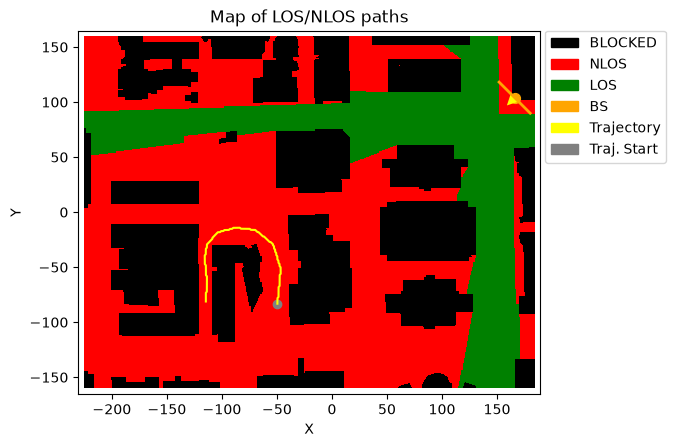

In [3]:
txBearingAngle = -135                           # Point the TX panel toward the center of the map

bwp = BandwidthPart(numRbs=12, spacing=15)      # Create a bandwidth part

trjPoints = np.array([[-50, -83], [-47, -51], [-54, -29], [-70, -16], [-88, -14],
                      [-104, -18], [-114, -29], [-116, -42], [-114, -63], [-115, -81]])
trajectory = dmData.trajectoryFromPoints(trjPoints, bwp, speedMps=15)

trajectory.print()                              # Print the trajectory information
ax = dmData.drawMap("LOS-NLOS", trajectory)     # Draw the map with the trajectory
dmData.drawBsPanel(ax, txBearingAngle)          # Draw the base station antenna panel

In [4]:
random.setSeed(123)                 # Make results reproducible
numSlots = trajectory.numPoints     # Total number of slots = number of points on the trajectory
prgSize = 0                         # Set to 0 for wideband, 2 or 4 for subband precoding

# Note:
# Since our goal is to show that different UE locations along a DeepMIMO trajectory experience different 
# BLER/throughput, we should not normalize the channel gain independently at each location. Per-location
# gain normalization would remove exactly the large-scale variation we want to observe. So, we set 
# the 'normalizeGains' to 'False' in our channel model below and use a fixed noise power.

# Calculating the noise power:
k = 1.380649e-23        # Boltzmann constant (joules per kelvin)
tempK = 290.0           # Temperature in kelvin
nf = 8                  # Receiver noise figure (dB)
noiseVarFreq = k*tempK*bwp.spacing*1000*toLinear(nf)

# Creating a trajectory-based channel model:
channel = TrjChannel(bwp, trajectory, 
                     normalizeGains = False,
                     txAntenna = AntennaPanel([1,4], polarization='x'),     # 8 TX antennas
                     txOrientation = [txBearingAngle,0,0],                  # BS antenna orientation
                     rxAntenna = AntennaPanel([1,1], polarization='x',      # 2 RX antennas
                                              beamWidth=[65,360]))          # Omnidirectional

# Create a typical CSI-RS configuration
csiRsConfig = CsiRsConfig.beamformingConfig(bwp, channel.txAntenna.numPorts, sweepsPerSlot=4)
# csiRsConfig.print()                   # Uncomment to print CSI-RS configuration details

# Get the CSI resource sets for beam sweeping, beam probing, and RI/PMI/CQI feedback
sweepSet, probeSet, pmiSet = csiRsConfig.csiRsSetList   

# Create CSI reports and a CsiReportMan object for the CSI-RS configuration
csiReportMan = CsiReportMan.beamformingReports(csiRsConfig, channel.txAntenna, 
                                               prgSize=prgSize, allowedRanks=[1,2], cqiTable=2)
# csiReportMan.print()                  # Uncomment to print CSI report configuration details

# Get the CSI report objects for beam sweeping, beam probing, and RI/PMI/CQI feedback
sweepRep, probeRep, pmiRep = csiReportMan.csiReports

# Initialize beam sweeping/probing parameters
numPhi = len(sweepSet)                  # Number of horizontal beams
numTheta = 1                            # Number of vertical beams (restrict sweeping to azimuth)
sweepWs, sweepBeams = channel.txAntenna.getSweepingBeams(numTheta, numPhi)
probeWs, probeBeams = None, None                # Probing weight vectors and beam angles
sweepCri, probeCri = None, None                 # Most recent CRI for sweeping and probing  
probePhiLocal, probePhiGlobal = None, None      # Best probing beam azimuth angle
rawCqi = None                                   # Most recent CQI feedback (before OLLA adjustment)

pdsch = None                            # PDSCH is created when a CQI report is available
harq = None                             # HARQ is created only once when the first CQI is received
olla = None                             # OLLA is created only once when the first CQI is received
precoder = None                         # The precoder based on the most recently received PMI
pmiW = None                             # The steering vector used by the most recent RI/PMI/CQI CSI-RS resources
pdschW = None                           # The steering vector used by PDSCH (consistent with precoder from PMI)

# Historical values:
beamAngles = []                         # Azimuth beam angles (probePhiGlobal) for each slot
cqiRep = []                             # Reported CQI values
cqiAdj = []                             # Adjusted CQI values
ris = []                                # RI (number of layers)
blockErrorFlags = []                    # 1 for each transport block error and 0 otherwise
rxBits = []                             # Number of received bits for each transmission
minMse, maxMse = 100, 0

t0 = time.monotonic()
print(f"\nSimulating end-to-end communication for {numSlots} slots on the trajectory ...")
print(" Slot   TX Blk  RX Blk   BLER   Beam Ang  OLLA Ofst  CQI(Rep)  RI    Mod.   Coderate  Trj. Time  Exe. Time")
print("------  ------  ------  ------  --------  ---------  --------  ---  ------  --------  ---------  ---------")
for slotNo in range(numSlots):
    # Process CSI feedback
    csiReportInfo = csiReportMan.getFeedback()              # Get all available CSI reports from CsiReport objects
    for reportId, csiFeedback in csiReportInfo.items():     # Process the CSI feedback for each report
        if reportId == sweepRep.reportId:                   # Beam-sweeping report
            sweepCri = csiFeedback.cri.cri                  # CSI-RS resource ID of the best beam
            probeSet.trigger()                              # Trigger the probing CSI-RS resource set
            probeRep.trigger()                              # Trigger the probing report
        
        elif reportId == probeRep.reportId:                 # Beam-probing report
            probeCri = csiFeedback.cri.cri                  # CSI-RS resource ID of the best beam
            beamIdx = probeCri - len(sweepSet) - 1          # Index of the best beam
            pmiSet.active=True                              # Activate RI/PMI/CQI CSI-RS resources
            pmiRep.active=True                              # Activate RI/PMI/CQI measurements
            
            # Update the best probing beam azimuth angle in local and global coordinates
            probePhiLocal = probeBeams[1][beamIdx]
            _, probePhiGlobal = AntennaPanel.local2Global( probeBeams[0][beamIdx],
                                                           probePhiLocal,
                                                           channel.txOrientation)
        
        elif reportId == pmiRep.reportId:                   # RI/PMI/CQI report
            precoder = csiFeedback.pmi.wbW if csiFeedback.pmi.sbWs is None else csiFeedback.pmi.sbWs
            pdschW = pmiW
            numLayers = csiFeedback.ri.ri                   # Set number of layers based on RI feedback
            if "cqi" in pmiRep.quantity.lower():    rawCqi = csiFeedback.cqi.cqi
        else:
            assert False, f"Unknown report: {reportId}"

    # Create a transmitted resource grid
    txGrid = bwp.createGrid(channel.txAntenna.numEl)

    # If we have a CQI report, transmit PDSCH data
    if rawCqi is not None:
        cqi = rawCqi if olla is None else olla.adjustCqi(rawCqi)    # Adjust the raw CQI received in the report
        modulation, coderateX1024 = pmiRep.getModRate(cqi)          # Get modulation and code rate based on CQI
        coderate = coderateX1024/1024
        pdsch = PDSCH(bwp, numLayers=numLayers, csiRsConfig=csiRsConfig, modulation=modulation, prgSize=prgSize)
        pdsch.setDMRS(additionalPos=2)                              # DMRS configuration
        if harq is None:
            # Create HARQ and OLLA objects the first time
            harq = pdsch.getHarq(coderates = coderate,              # Code rate used by the LDPC codec
                                 harqType="IR",                     # Use Incremental Redundancy
                                 numProc=16)                        # Number of HARQ processes
            olla = OLLA(harq, pmiRep.cqiTable, fixedOffset=-2)      # Create the link adaptation object
        else:
            # We already have a HARQ and OLLA. Update HARQ's LDPC codec if needed.
            ldpcModulation = harq.ldpcCodec.modulations[0]
            ldpcCoderate =  harq.ldpcCodec.coderates[0]
            ldpcNumLayers = harq.ldpcCodec.cwCodecs[0].numLayers
            if (numLayers != ldpcNumLayers) or (modulation != ldpcModulation) or (coderate != ldpcCoderate):
                harq.setLdpc( pdsch.getLdpcCodec(coderates=coderate) )  # Update HARQ's LDPC codec

        pdsch.initGrid()                                        # Create and initialize PDSCH's internal grid
        numBits = pdsch.getBitCapacity()[0]                     # Number of bits available in the resource grid
        tbs = harq.ldpcCodec.txBlockSizes[0]                    # Transport block size (for the first codeword)
        if harq.needNewData[0]: txBlock = random.bits(tbs)      # Create random bits for new transmissions
        else:                   txBlock = None                  # Set to None indicating a retransmission

        rateMatchedCBs = harq.encode(txBlock, numBits)          # LDPC encode the transport block  
        pdsch.setPdschData(rateMatchedCBs)                      # Map/modulate the data to the resource grid
        pdsch.precodeTo(txGrid, precoder, pdschW)               # Precode PDSCH data into the txGrid

    # Process and add CSI-RS to the txGrid
    csiRsResources = csiRsConfig.getResources()
    for csiSetId, setResources in csiRsResources.items():
        if csiSetId == sweepSet.rsId:                           # CSI-RS for beam sweeping
            for resourceId, (lIdx, kIdx, sweepReValues) in setResources.items():
                b = resourceId-1                                # Beam index
                w = sweepWs[:,b:b+1]                            # nt x 1
                # sweepReValues is a 1 x numCsiRsRE matrix. nt x 1 * 1 x numCsiRsRE = nt x numCsiRsRE
                txGrid[:,lIdx, kIdx] = (w * sweepReValues, "CSIRS_NZP", resourceId)
        
        elif csiSetId == probeSet.rsId:                         # CSI-RS for beam probing
            b = sweepCri-1                                      # Index of best sweeping beam
            theta0, phi0 = sweepBeams[0][b], sweepBeams[1][b]   # Best sweeping beam angles
            probeWs, probeBeams = channel.txAntenna.getProbingBeams(theta0, phi0, len(probeSet), polStrategy='equal')
            for resourceId, (lIdx, kIdx, probeReValues) in setResources.items():
                b = resourceId - len(sweepSet) - 1              # Beam index
                w = probeWs[:,b:b+1]                            # nt x 1
                # probeReValues is a 1 x numCsiRsRE matrix. nt x 1 * 1 x numCsiRsRE = nt x numCsiRsRE
                txGrid[:,lIdx, kIdx] = (w * probeReValues, "CSIRS_NZP", resourceId)

        elif csiSetId == pmiSet.rsId:                           # CSI-RS for RI/PMI/CQI
            # Use the beamforming vector corresponding to the best probed beam. This will also be
            # saved to pdschW when the report for this CSI-RS is received. pdschW is then combined with
            # the PMI procoder to precode PDSCH.
            wIdx = probeCri - len(sweepSet) - 1             # Index of the best probing beam from CRI
            pmiW = probeWs[:,wIdx:wIdx+1].copy()            # shape: nt x 1
            for resourceId, (lIdx, kIdx, pmiReValues) in setResources.items():
                txGrid[:,lIdx, kIdx] = (pmiW * pmiReValues, "CSIRS_NZP", resourceId)    

    channelMatrix = channel.getChannelMatrix()                  # Get channel matrix from the channel model
    rxGrid = txGrid.applyChannel(channelMatrix)                 # Apply the channel in the frequency domain
    noisyRxGrid = rxGrid.addNoise(noiseVar=noiseVarFreq)        # Add noise

    # Receiver side:
    if pdsch is not None:
        effChannelMatrix = channel.getEffChannel(channelMatrix, precoder, pdschW)   # Perfect channel knowledge
        eqGrid, llrScales = pdsch.equalize(noisyRxGrid, effChannelMatrix)   # Equalize received PDSCH data
        llrs = pdsch.getLLRs(eqGrid, llrScales)                             # Demodulate and get LLRs
        decodedTxBlocks, crcMatches = harq.decode(llrs)                     # Use HARQ to decode the LLRs

        beamAngles += [ probePhiGlobal ]                                    # Record the best probe beam azimuth
        cqiRep += [ rawCqi ]                                                # Record the reported CQI
        cqiAdj += [ cqi ]                                                   # Record the adjusted CQI
        ris += [ numLayers ]                                                # Record number of layers
        rxBits += [ tbs if crcMatches[0][0] else 0 ]                        # Record successfully received bits
        blockErrorFlags += [ 0 if crcMatches[0][0] else 1 ]                 # Record the block-error flag
    else:   # No PDSCH yet -> use zeros
        beamAngles += [ 0 ]
        cqiRep += [ 0 ]
        cqiAdj += [ 0 ]
        ris += [0]
        rxBits += [ 0 ]
        blockErrorFlags += [ 0 ]
    
    csiReportMan.processRxGrid(noisyRxGrid, csiRsResources) # Process the CSI-RS resources in the 'noisyRxGrid'
    dt = time.monotonic()-t0                                # Total time spent so far

    if pdsch is None:
        print(f"\r{slotNo+1:^6d}  {0:^6d}  {0:^6d}  {'N/A':^6s}  "
              f"{'N/A':^8s}  {"N/A":^9s}  {'N/A':^8s}  {'N/A'}  {'N/A':^6s}  {'N/A':^8s}  "  
              f"{channel.trajectory.cur.time:^9.2f}  {dt:^9.2f}", end='')
    else:
        # Note: Using bler1st, which is the first-transmission BLER
        print(f"\r{slotNo+1:^6,d}  {harq.totalTxBlocks:^6,d}  {harq.totalRxBlocks:^6,d}  {harq.bler1st:^6.3f}  "
              f"{probePhiLocal:^8.1f}  {olla.cqiOffset[0]:^9.2f}  {f'{cqi}({rawCqi})':^8s}  {numLayers:^3d}  "
              f"{modulation:^6s}  {f'{coderateX1024}/1024':^8s}  {channel.trajectory.cur.time:^9.2f}  {dt:^9.2f}",
              end='')
        
    channel.goNext()                                                # Move to the next slot and trajectory point
    if harq is not None: harq.goNext()                              # Go to the next HARQ process



Simulating end-to-end communication for 12378 slots on the trajectory ...
 Slot   TX Blk  RX Blk   BLER   Beam Ang  OLLA Ofst  CQI(Rep)  RI    Mod.   Coderate  Trj. Time  Exe. Time
------  ------  ------  ------  --------  ---------  --------  ---  ------  --------  ---------  ---------
12,378  12,364  11,187  9.717    -15.5      1.63       6(6)     1   16QAM   616/1024    12.38     459.04  

In [5]:
# Since we are averaging the angles, we need to make sure they are continuous:
# Local angle range: -90 to 90
# Global angle range: 135 .. -45
# Adjusted global angle range: 135 .. 315  (Add 360 to the negative values)
beamAngles = np.array(beamAngles)
beamAngles[beamAngles<0] += 360     # Range: 135 .. 315

# Callback used to initialize and update the scenario map and the graphs below it
def handleGraph(request, ax, trajectory, points=None):
    if request=="Config":
        # CQI 
        ax[0].set_xlim(0,trajectory.numPoints)
        ax[0].set_ylim(1,16)
        ax[0].set_title("CQI")
        ax[0].set_xlabel("Trajectory points")
        ax[0].grid()
        ax[0].plot([0], [cqiRep[0]], 'red', markersize=1, label="Reported")
        ax[0].plot([0], [cqiAdj[0]], 'orange', markersize=1, label="Adjusted")
        ax[0].legend(fontsize=8)
        
        # RI 
        ax[1].set_xlim(0,trajectory.numPoints)
        ax[1].set_ylim(0.8,2.2)
        ax[1].set_title("RI (Number of layers)")
        ax[1].set_xlabel("Trajectory points")
        ax[1].grid()
        ax[1].plot([0], [np.mean(ris[0])], 'blue', markersize=1)

        # Use the following to show BLER in the 3rd graph
        # ax[2].set_xlim(0,trajectory.numPoints)
        # ax[2].set_ylim(0,22)
        # ax[2].set_title("BLER (%)")
        # ax[2].set_xlabel("Trajectory points")
        # ax[2].grid()
        # ax[2].plot([0], [0], 'green', markersize=1)

        # Use the following to show throughput in the 3rd graph
        ax[2].set_xlim(0,trajectory.numPoints)
        ax[2].set_ylim(0.1e7,2.5e7)
        ax[2].set_title("Throughput (bps)")
        ax[2].set_xlabel("Trajectory points")
        ax[2].grid()
        ax[2].plot([0], [0], 'green', markersize=1)

    elif request=="ConfigMap":
        ax.set_title("CSI Feedback and OLLA Link Adaptation along a UE Trajectory")
        ax.drawBsPanel(txBearingAngle)   # Draw TX antenna panel
        ax.drawBeamArrow(txBearingAngle, 'cyan', length=50)

    elif request=="Draw":
        p0, p1 = points
        return (ax[0].addNewPoint(p1, np.mean(cqiRep[p0: p1]), 0),                          # Reported CQI
                ax[0].addNewPoint(p1, np.mean(cqiAdj[p0: p1]), 1),                          # Adjusted CQI
                ax[1].addNewPoint(p1, np.mean(ris[p0:p1])),                                 # RI
                # ax[2].addNewPoint(p1, np.mean(blockErrorFlags[p0: p1])*100 )              # BLER
                ax[2].addNewPoint(p1, np.sum(rxBits[p0:p1])/((p1-p0)/bwp.avgSlotDuration) ))# throughput
        
    elif request=="DrawOnMap":
        p0, p1 = points
        if p0>0:
            meanPhi = np.mean(beamAngles[p0:p1])
            return (ax.updateBeamArrow(meanPhi),)

# Create the animation and display it below
anim = dmData.animateTrajectory(trajectory, numGraphs=3, pointsPerFrame=200, 
                                graphCallback=handleGraph, fileName='AnimateLA.gif',
                                lastFrameDur=3000)  # Freeze on last frame for 3 seconds
display(Markdown("![demo](AnimateLA.gif)"))

# Alternatively, the following code provides better control over running 
# the animation. Note that for this method to work, you should not pass a 
# 'fileName' to the 'animateTrajectory' function.
#    # Increase the animation memory limit for HTML-based animation display
#    matplotlib.rcParams['animation.embed_limit'] = 100000000
#    anim = dmData.animateTrajectory(trajectory, numGraphs=3, pointsPerFrame=100, 
#                                    graphCallback=handleGraph)
#    HTML(anim.to_jshtml())

![demo](AnimateLA.gif)